In [1]:
import pandas as pd
import h5py as h5
import sys
sys.path.append('../')
import matplotlib.pyplot as plt
import numpy as np

In [2]:
csv = pd.read_csv('../wandb_csv/results_pretrained_baselines.csv')

In [3]:
# Remove '-LinearClassification' from Group column and set data.percentage to 0 for those rows
csv.loc[csv['Group'].str.contains('-LinearClassification', na=False) | (csv['Group'].str.replace('-LinearClassification', '') != csv['Group']), 'data.percentage'] = 0

csv.loc[csv['Group'].str.contains('DiViT-LinearClassification', na=False), 'Group'] = csv.loc[csv['Group'].str.contains('DiViT-LinearClassification', na=False), 'Group'].str.replace('DiViT-LinearClassification', 'DiViT-VICReg')
csv.loc[csv['Group'].str.contains('DiViT-Large-LinearClassification', na=False), 'Group'] = csv.loc[csv['Group'].str.contains('DiViT-LinearClassification', na=False), 'Group'].str.replace('DiViT-Large-LinearClassification', 'DiViT-Large-VICReg')
csv.loc[csv['Group'].str.contains('-LinearClassification', na=False), 'Group'] = csv.loc[csv['Group'].str.contains('-LinearClassification', na=False), 'Group'].str.replace('-LinearClassification', '')

# Change all underscores to hyphens in Group column
csv['Group'] = csv['Group'].str.replace('_', '-')
# If data.percentage
csv.loc[csv['data.percentage'] > 1, 'data.percentage'] = 1.0


In [4]:
csv_grouped_by_group_and_percentage = csv.groupby(['Group', 'data.percentage'])

In [5]:
# Explore the data structure
print("Column names:")
print(csv.columns.tolist())
print("\nFirst few rows:")
print(csv.head())
print("\nUnique groups:")
print(csv['Group'].unique())
print("\nUnique data percentages:")
print(sorted(csv['data.percentage'].unique()))

Column names:
['Name', 'Group', 'State', 'Notes', 'User', 'Tags', 'Created', 'Runtime', 'Sweep', 'callbacks.early_stopping._target_', 'callbacks.early_stopping.check_finite', 'callbacks.early_stopping.min_delta', 'callbacks.early_stopping.mode', 'callbacks.early_stopping.monitor', 'callbacks.early_stopping.patience', 'callbacks.early_stopping.strict', 'callbacks.early_stopping.verbose', 'callbacks.lr_monitor._target_', 'callbacks.lr_monitor.log_momentum', 'callbacks.lr_monitor.logging_interval', 'callbacks.model_checkpoint._target_', 'callbacks.model_checkpoint.auto_insert_metric_name', 'callbacks.model_checkpoint.dirpath', 'callbacks.model_checkpoint.filename', 'callbacks.model_checkpoint.mode', 'callbacks.model_checkpoint.monitor', 'callbacks.model_checkpoint.save_top_k', 'callbacks.model_checkpoint.save_weights_only', 'callbacks.model_checkpoint.verbose', 'callbacks.model_summary._target_', 'callbacks.model_summary.max_depth', 'callbacks.rich_progress_bar._target_', 'data._target_',

In [6]:
# Calculate mean and std of test F1 scores for each group and data percentage
# Look for test F1 score column (it might be named 'test/f1', 'test_f1', or similar)
f1_columns = [col for col in csv.columns if 'f1' in col.lower() and 'test' in col.lower()]
print("Available F1 score columns:")
print(f1_columns)

# If we find the test F1 column, use it; otherwise show all columns with 'test' in name
test_columns = [col for col in csv.columns if 'test' in col.lower()]
print("\nAll test-related columns:")
print(test_columns)

Available F1 score columns:
['test/f1', 'test/f1_lc']

All test-related columns:
['test/f1', 'test/f1_lc', 'test/loss', 'test/loss_lc']


In [7]:
# Calculate mean and std of test F1 scores grouped by Group and data.percentage
f1_stats = csv.groupby(['Group', 'data.percentage'])['test/f1'].agg(['mean', 'std']).reset_index()

# Display the results
print("F1 Score Statistics by Group and Data Percentage:")
print(f1_stats)

# Pivot the data for easier plotting
f1_pivot = f1_stats.pivot(index='data.percentage', columns='Group', values=['mean', 'std'])

print(f"\nPivoted data shape: {f1_pivot.shape}")
print(f1_pivot.head())

F1 Score Statistics by Group and Data Percentage:
                 Group  data.percentage      mean       std
0                 ATAT             0.01  0.138138  0.037615
1                 ATAT             0.10  0.416285  0.007398
2                 ATAT             0.25  0.544820  0.004869
3                 ATAT             0.50  0.631280  0.011452
4                 ATAT             1.00  0.684917  0.011871
5                  DiT             0.01  0.388630  0.024968
6                  DiT             0.10  0.699314  0.009604
7                  DiT             0.25  0.754092  0.007856
8                  DiT             0.50  0.797746  0.003723
9                  DiT             1.00  0.829032  0.004912
10          DiT-SimCLR             0.00  0.737507  0.004227
11          DiT-SimCLR             0.01  0.610766  0.019455
12          DiT-SimCLR             0.10  0.783840  0.006727
13          DiT-SimCLR             0.25  0.814168  0.005073
14          DiT-SimCLR             0.50  0.832868 

Groups: ['ATAT' 'DiT' 'DiT-SimCLR' 'DiT-VICReg' 'DiViT-Large' 'DiViT-Large-VICReg'
 'DiViT-VICReg']
Data percentages: [np.float64(0.0), np.float64(0.01), np.float64(0.1), np.float64(0.25), np.float64(0.5), np.float64(1.0)]


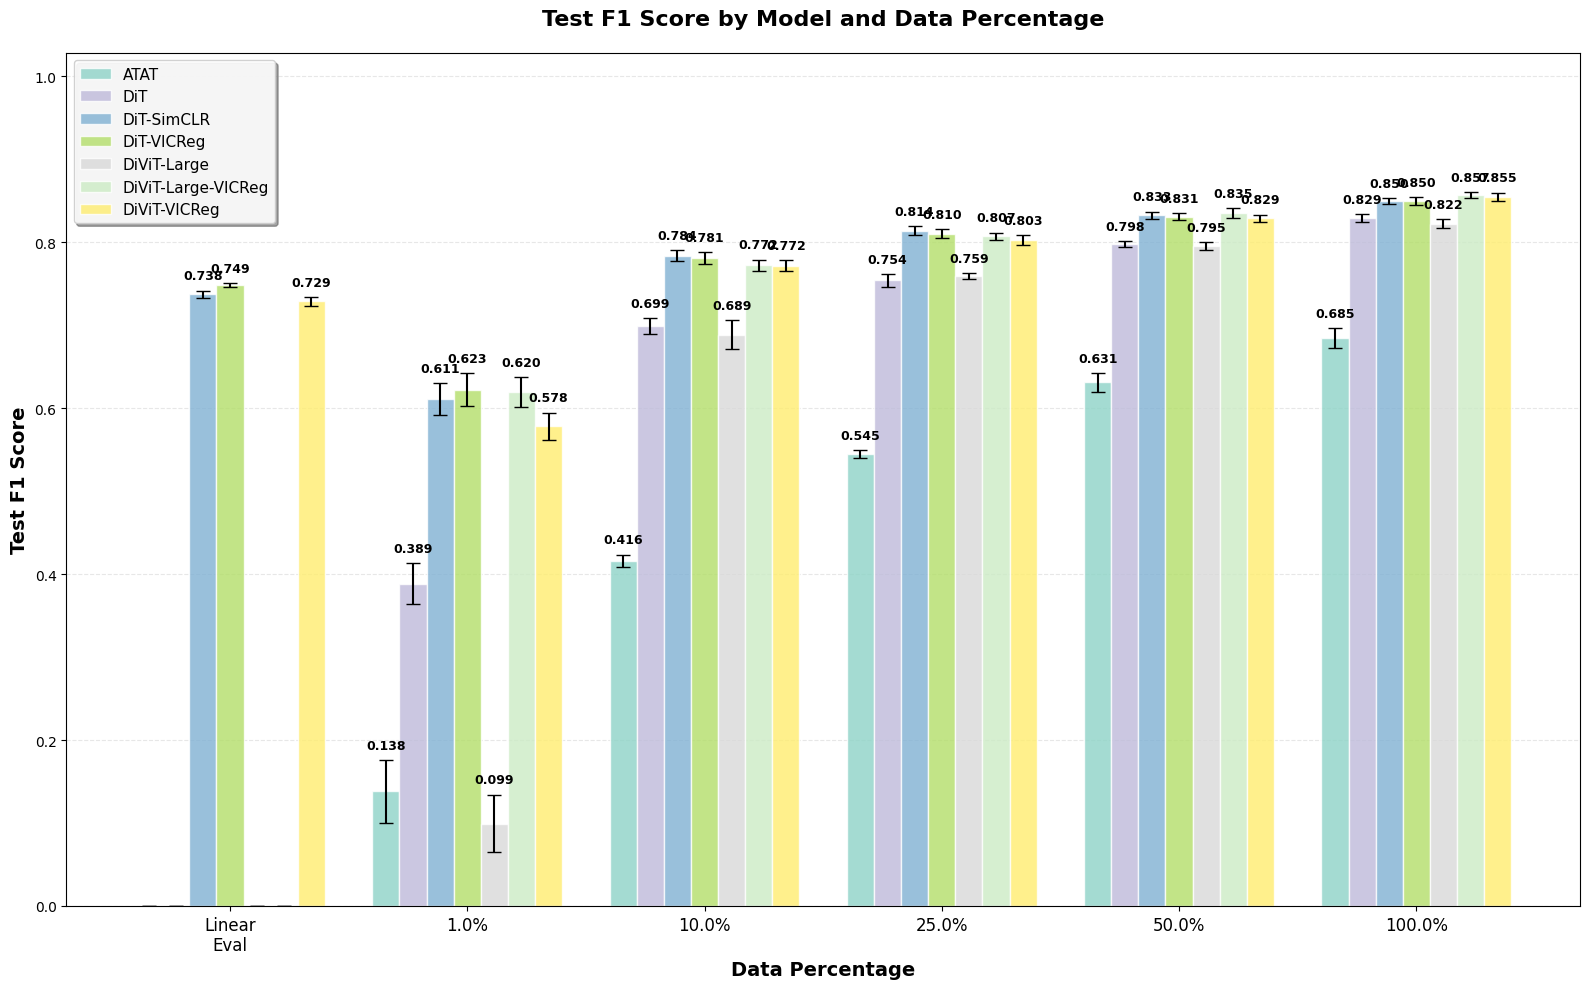

In [8]:
# Create a comprehensive bar plot
fig, ax = plt.subplots(1, 1, figsize=(16, 10))

# Get unique groups and data percentages
groups = f1_stats['Group'].unique()
percentages = sorted(f1_stats['data.percentage'].unique())

print(f"Groups: {groups}")
print(f"Data percentages: {percentages}")

# Define colors for different groups
colors = plt.cm.Set3(np.linspace(0, 1, len(groups)))
group_colors = dict(zip(groups, colors))

# Set up bar positions
bar_width = 0.8 / len(groups)
x_positions = np.arange(len(percentages))

# Create bars for each group
for i, group in enumerate(groups):
    group_data = f1_stats[f1_stats['Group'] == group]
    
    # Get mean and std values for this group across all percentages
    means = []
    stds = []
    
    for pct in percentages:
        group_pct_data = group_data[group_data['data.percentage'] == pct]
        if not group_pct_data.empty:
            means.append(group_pct_data['mean'].iloc[0])
            stds.append(group_pct_data['std'].iloc[0])
        else:
            means.append(0)  # No data for this percentage
            stds.append(0)
    
    # Position bars for this group
    x_pos = x_positions + i * bar_width - (len(groups) - 1) * bar_width / 2
    
    # Create bars with error bars
    bars = ax.bar(x_pos, means, bar_width, yerr=stds, 
                  label=group, color=group_colors[group], 
                  alpha=0.8, capsize=5, edgecolor='white', linewidth=1)
    
    # Add value labels on top of bars
    for j, (bar, mean, std) in enumerate(zip(bars, means, stds)):
        if mean > 0:  # Only add labels for non-zero values
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + std + 0.01,
                   f'{mean:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Customize the plot
ax.set_title('Test F1 Score by Model and Data Percentage', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Data Percentage', fontsize=14, fontweight='bold')
ax.set_ylabel('Test F1 Score', fontsize=14, fontweight='bold')

# Set x-axis labels
ax.set_xticks(x_positions)
ax.set_xticklabels([
    'Linear\nEval' if pct == 0 else 
    f'{pct:.1%}' if pct <= 1 else 
    '100%' 
    for pct in percentages
], fontsize=12)

# Add grid and styling
ax.grid(True, alpha=0.3, axis='y', linestyle='--')
ax.set_axisbelow(True)
ax.set_ylim(0, max(f1_stats['mean']) * 1.2)

# Add legend
legend = ax.legend(loc='upper left', fontsize=11, framealpha=0.9, fancybox=True, shadow=True)

# Improve overall appearance
plt.tight_layout()
plt.show()

In [9]:
# Create a summary table for better readability
print("Summary Table: Test F1 Score Statistics")
print("="*60)

# Create a more readable summary table
summary_table = f1_stats.pivot(index='data.percentage', columns='Group', values=['mean', 'std'])

# Format the display
for pct in percentages:
    if pct == 0:
        print(f"\nLinear Evaluation:")
    elif pct <= 1:
        print(f"\nData Percentage: {pct:.1%}")
    else:
        print(f"\nData Percentage: 100%")
    print("-" * 40)
    
    pct_data = f1_stats[f1_stats['data.percentage'] == pct]
    
    for _, row in pct_data.iterrows():
        group = row['Group']
        mean_val = row['mean']
        std_val = row['std']
        print(f"{group:20}: {mean_val:.3f} ± {std_val:.3f}")

# Save the figure
plt.savefig('test_f1_scores_by_model_and_percentage.png', dpi=300, bbox_inches='tight')

Summary Table: Test F1 Score Statistics

Linear Evaluation:
----------------------------------------
DiT-SimCLR          : 0.738 ± 0.004
DiT-VICReg          : 0.749 ± 0.003
DiViT-VICReg        : 0.729 ± 0.005

Data Percentage: 1.0%
----------------------------------------
ATAT                : 0.138 ± 0.038
DiT                 : 0.389 ± 0.025
DiT-SimCLR          : 0.611 ± 0.019
DiT-VICReg          : 0.623 ± 0.020
DiViT-Large         : 0.099 ± 0.035
DiViT-Large-VICReg  : 0.620 ± 0.018
DiViT-VICReg        : 0.578 ± 0.016

Data Percentage: 10.0%
----------------------------------------
ATAT                : 0.416 ± 0.007
DiT                 : 0.699 ± 0.010
DiT-SimCLR          : 0.784 ± 0.007
DiT-VICReg          : 0.781 ± 0.007
DiViT-Large         : 0.689 ± 0.017
DiViT-Large-VICReg  : 0.772 ± 0.007
DiViT-VICReg        : 0.772 ± 0.007

Data Percentage: 25.0%
----------------------------------------
ATAT                : 0.545 ± 0.005
DiT                 : 0.754 ± 0.008
DiT-SimCLR          :

<Figure size 640x480 with 0 Axes>